# LSTM

## Import libraries

In [1]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [2]:
TARGET_COLUMN = "close"
TARGET_COLUMN

'close'

In [3]:
FROM_DATE = "2000-01-01"
TO_DATE = "2020-31-12"

In [4]:
INPUT_SIZE = 40
OUTPUT_SIZE = 10
NUMBER_OF_TRAIN_WINDOW = 2000
NUMBER_OF_VALIDATION_WINDOW = 200
NUMBER_OF_TEST_WINDOW = 200

## Hyper Parameters

In [5]:
MAX_EPOCHS = 100
LEARNING_RATE = 0.0001
PATIENCE = 20

## Start

### Get data

In [6]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [7]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [8]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [9]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [10]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [11]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [12]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [13]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [14]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [15]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
7457,2019-08-18,980.986667,985.523333,977.740000,980.686667,120713717.0
7458,2019-09-14,979.736667,989.013333,979.540000,988.100000,139949737.0
7459,2020-07-19,871.600000,873.036667,864.896667,864.940000,244504907.0
7460,2020-11-01,925.863333,931.226667,919.826667,930.943333,266836427.0


### Create plot

In [16]:
my_visualizer = Visualizer(logger=my_logger)

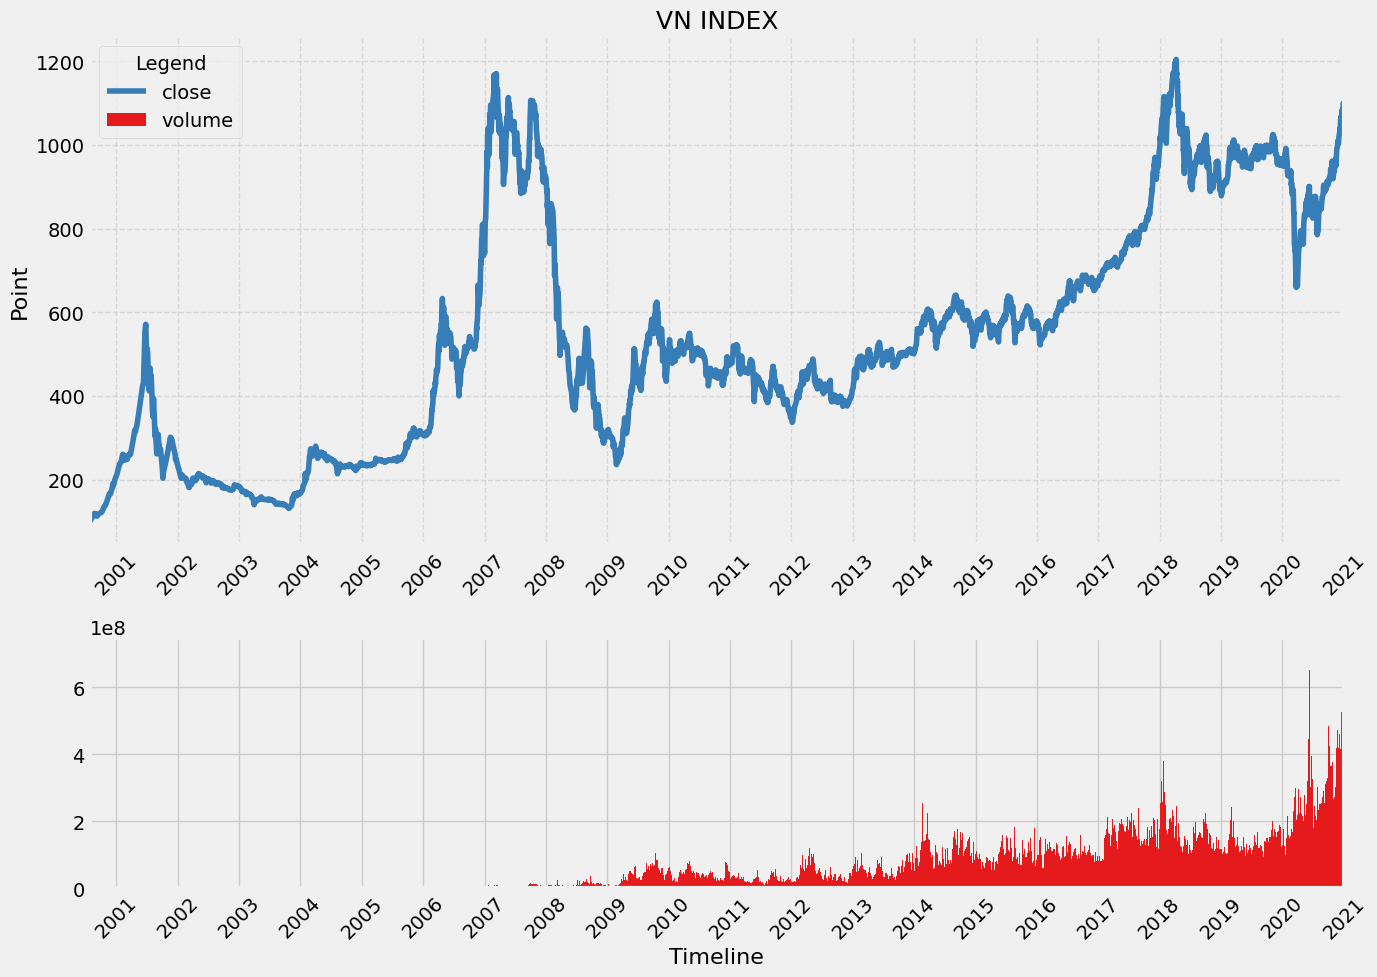

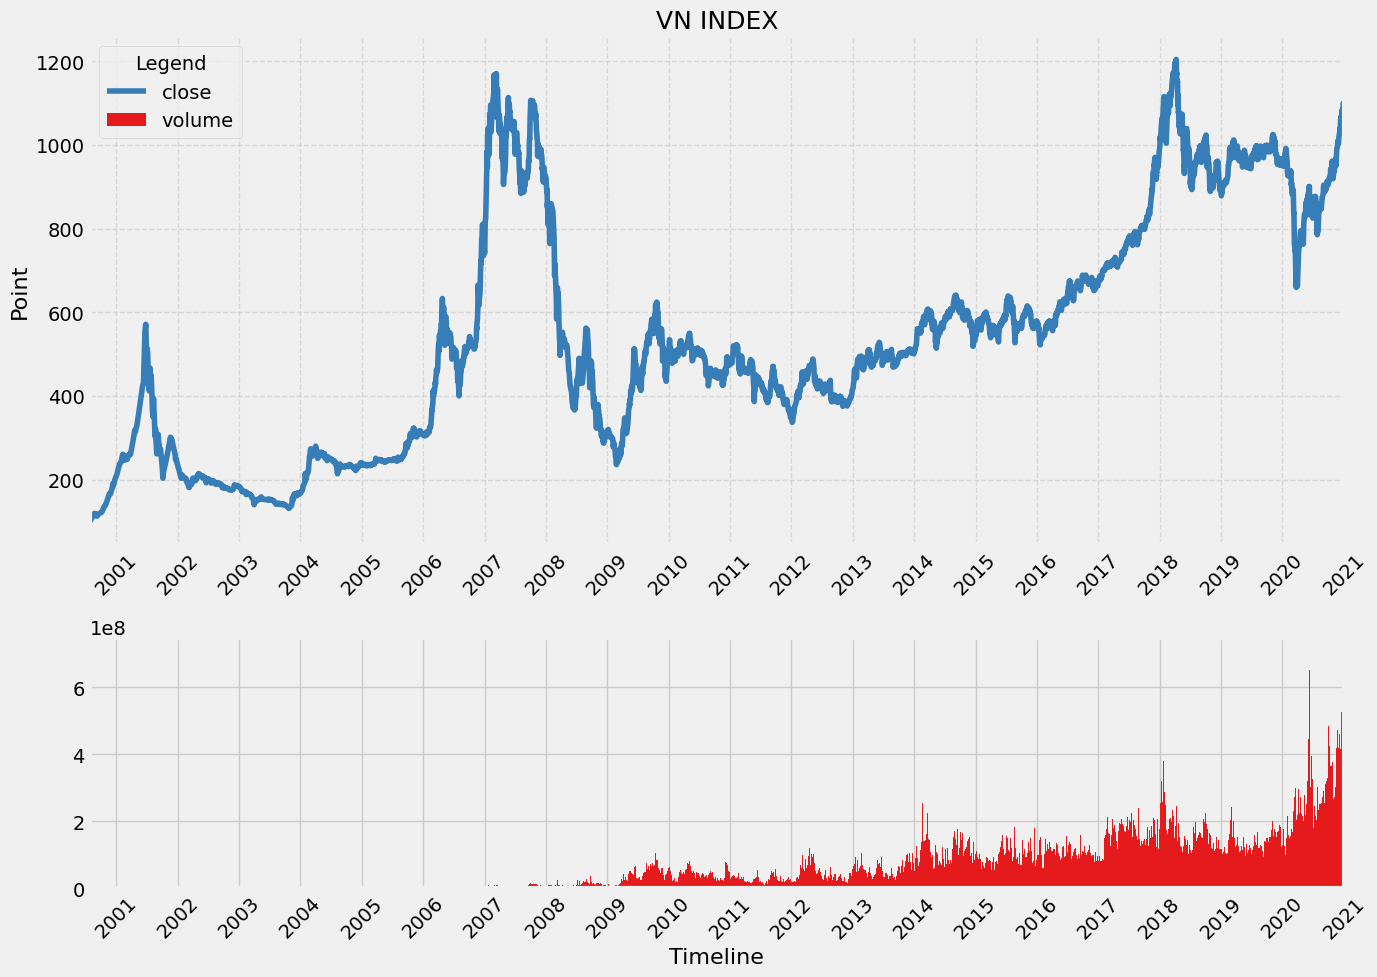

In [17]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create train validation test 

In [18]:
data = vn_index_transform_sub_df[["close", "volume"]].copy()

### Move the target column to the last column

In [19]:
cols = [col for col in data.columns if col != "close"] + ["close"]
data = data[cols]

In [20]:
data

,volume,close
0,13100.0,106.920000
1,14500.0,107.780000
2,15900.0,108.640000
3,14750.0,109.500000
4,13600.0,110.360000
...,...,...
7457,120713717.0,980.686667
7458,139949737.0,988.100000
7459,244504907.0,864.940000
7460,266836427.0,930.943333


In [21]:
data.shape

(7462, 2)

In [22]:
train_set_range = (0, INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + OUTPUT_SIZE)
validation_set_range = (
    train_set_range[1],
    train_set_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_VALIDATION_WINDOW,
)
test_set_range = (
    validation_set_range[1],
    validation_set_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_TEST_WINDOW,
)
print(train_set_range, validation_set_range, test_set_range)

(0, 2050) (2050, 2300) (2300, 2550)


In [23]:
train_set = np.array(data[train_set_range[0] : train_set_range[1]])
validation_set = np.array(data[validation_set_range[0] : validation_set_range[1]])
test_set = np.array(data[test_set_range[0] : test_set_range[1]])

In [24]:
train_set[:5, :]

array([[13100.  ,   106.92],
       [14500.  ,   107.78],
       [15900.  ,   108.64],
       [14750.  ,   109.5 ],
       [13600.  ,   110.36]])

In [25]:
train_set.shape

(2050, 2)

In [26]:
validation_set[:5, :]

array([[1.19247e+06, 4.60680e+02],
       [1.62091e+06, 4.39660e+02],
       [1.77980e+06, 4.34240e+02],
       [1.53222e+06, 4.41270e+02],
       [1.39470e+06, 4.39570e+02]])

In [27]:
validation_set.shape

(250, 2)

In [28]:
test_set[:5, :]

array([[4.77544000e+06, 9.65720000e+02],
       [3.68049000e+06, 1.00112000e+03],
       [6.48460000e+06, 9.98090000e+02],
       [4.30539000e+06, 9.68880000e+02],
       [4.00789300e+06, 9.56313333e+02]])

In [29]:
len(test_set)

250

In [30]:
# Create feature_scaler
feature_scaler = MinMaxScaler()

# Fit scaler ONLY on train data
feature_train_scaler = feature_scaler.fit_transform(train_set)

feature_validation_scaled = feature_scaler.transform(validation_set)

# Transform test data using same feature_scaler
feature_test_scaled = feature_scaler.transform(test_set)

print("Train scaled shape:", feature_train_scaler.shape)
print("Validation scaled shape:", feature_validation_scaled.shape)
print("Test scaled shape:", feature_test_scaled.shape)

Train scaled shape: (2050, 2)
Validation scaled shape: (250, 2)
Test scaled shape: (250, 2)


In [31]:
feature_scaler.data_min_, feature_scaler.data_max_

(array([1000.        ,  106.34666667]), array([1.4322974e+08, 6.3269000e+02]))

In [32]:
# Create target_scaler
target_scaler = MinMaxScaler()

# Fit scaler ONLY on train data
target_train_scaler = target_scaler.fit_transform(train_set[:, -1].reshape(-1, 1))

target_validation_scaled = target_scaler.transform(validation_set[:, -1].reshape(-1, 1))

# Transform test data using same featuretarget_scaler_scaler
target_test_scaled = target_scaler.transform(test_set[:, -1].reshape(-1, 1))

print("Train scaled shape:", target_train_scaler.shape)
print("Validation scaled shape:", target_validation_scaled.shape)
print("Test scaled shape:", target_test_scaled.shape)

Train scaled shape: (2050, 1)
Validation scaled shape: (250, 1)
Test scaled shape: (250, 1)


In [33]:
target_scaler.data_min_, target_scaler.data_max_

(array([106.34666667]), array([632.69]))

In [34]:
train_inputs = []
train_outputs = []

for i in range(NUMBER_OF_TRAIN_WINDOW + 1):
    train_input = feature_train_scaler[i : i + INPUT_SIZE]
    train_inputs.append(train_input)
    train_output = feature_train_scaler[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE][
        :, -1
    ]
    train_outputs.append(train_output)

train_inputs = torch.tensor(np.array(train_inputs), dtype=torch.float32)
train_outputs = torch.tensor(np.array(train_outputs), dtype=torch.float32)

In [35]:
train_inputs[0]

tensor([[8.4480e-05, 1.0893e-03],
        [9.4255e-05, 2.7232e-03],
        [1.0403e-04, 4.3571e-03],
        [9.6000e-05, 5.9910e-03],
        [8.7971e-05, 7.6249e-03],
        [7.9125e-05, 9.8035e-03],
        [7.4706e-05, 1.0893e-02],
        [1.1415e-04, 1.2527e-02],
        [1.5360e-04, 1.4161e-02],
        [1.0927e-04, 1.5795e-02],
        [6.4931e-05, 1.7428e-02],
        [1.2358e-04, 1.8518e-02],
        [1.8223e-04, 1.9607e-02],
        [2.4087e-04, 2.0696e-02],
        [5.0583e-04, 2.2330e-02],
        [7.7080e-04, 2.3964e-02],
        [7.1424e-04, 2.3850e-02],
        [6.5769e-04, 2.3736e-02],
        [6.6397e-04, 2.2571e-02],
        [6.7026e-04, 2.1406e-02],
        [6.7654e-04, 2.0240e-02],
        [7.7638e-04, 1.8483e-02],
        [8.7622e-04, 1.6725e-02],
        [7.7184e-04, 1.5035e-02],
        [6.6746e-04, 1.3344e-02],
        [5.6776e-04, 1.2690e-02],
        [5.1791e-04, 1.2363e-02],
        [4.6806e-04, 1.2037e-02],
        [4.1821e-04, 1.1710e-02],
        [3.784

In [36]:
train_inputs.shape

torch.Size([2001, 40, 2])

In [37]:
train_outputs[0]

tensor([0.0225, 0.0225, 0.0225, 0.0231, 0.0236, 0.0239, 0.0240, 0.0247, 0.0254,
        0.0263])

In [38]:
train_outputs.shape

torch.Size([2001, 10])

In [39]:
validation_inputs = []
validation_outputs = []

for i in range(NUMBER_OF_VALIDATION_WINDOW + 1):
    validation_input = feature_validation_scaled[i : i + INPUT_SIZE]
    validation_inputs.append(validation_input)
    validation_output = feature_validation_scaled[
        i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE
    ][:, -1]
    validation_outputs.append(validation_output)

validation_inputs = torch.tensor(np.array(validation_inputs), dtype=torch.float32)
validation_outputs = torch.tensor(np.array(validation_outputs), dtype=torch.float32)

In [40]:
validation_inputs[0]

tensor([[0.0083, 0.6732],
        [0.0113, 0.6333],
        [0.0124, 0.6230],
        [0.0107, 0.6363],
        [0.0097, 0.6331],
        [0.0090, 0.6222],
        [0.0083, 0.6114],
        [0.0076, 0.6005],
        [0.0093, 0.5672],
        [0.0123, 0.5575],
        [0.0123, 0.5916],
        [0.0128, 0.6254],
        [0.0139, 0.6101],
        [0.0145, 0.6025],
        [0.0082, 0.6214],
        [0.0166, 0.6154],
        [0.0083, 0.6195],
        [0.0131, 0.6405],
        [0.0137, 0.6538],
        [0.0142, 0.6672],
        [0.0148, 0.6806],
        [0.0185, 0.6726],
        [0.0204, 0.7028],
        [0.0226, 0.7162],
        [0.0227, 0.7143],
        [0.0193, 0.7142],
        [0.0159, 0.7141],
        [0.0125, 0.7141],
        [0.0177, 0.6911],
        [0.0127, 0.7068],
        [0.0118, 0.7081],
        [0.0088, 0.7050],
        [0.0092, 0.8890],
        [0.0112, 0.7157],
        [0.0151, 0.7263],
        [0.0216, 0.7342],
        [0.0147, 0.7311],
        [0.0205, 0.7445],
        [0.0

In [41]:
validation_inputs.shape

torch.Size([201, 40, 2])

In [42]:
validation_outputs[0]

tensor([0.7777, 0.7814, 0.7692, 0.7727, 0.7717, 0.7708, 0.7698, 0.7495, 0.7682,
        0.7577])

In [43]:
validation_outputs.shape

torch.Size([201, 10])

In [44]:
test_inputs = []
test_outputs = []

for i in range(NUMBER_OF_TEST_WINDOW + 1):
    test_input = feature_test_scaled[i : i + INPUT_SIZE]
    test_inputs.append(test_input)
    test_output = feature_test_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE][
        :, -1
    ]
    test_outputs.append(test_output)

test_inputs = torch.tensor(np.array(test_inputs), dtype=torch.float32)
test_outputs = torch.tensor(np.array(test_outputs), dtype=torch.float32)

In [45]:
test_inputs[0]

tensor([[0.0333, 1.6327],
        [0.0257, 1.7000],
        [0.0453, 1.6942],
        [0.0301, 1.6387],
        [0.0280, 1.6149],
        [0.0259, 1.5910],
        [0.0238, 1.5671],
        [0.0303, 1.5184],
        [0.0308, 1.5533],
        [0.0304, 1.5564],
        [0.0300, 1.5595],
        [0.0295, 1.5627],
        [0.0291, 1.5658],
        [0.0287, 1.5690],
        [0.0283, 1.5721],
        [0.0279, 1.5753],
        [0.0224, 1.5790],
        [0.0188, 1.5975],
        [0.0229, 1.6206],
        [0.0271, 1.6437],
        [0.0312, 1.6667],
        [0.0379, 1.7272],
        [0.0421, 1.7358],
        [0.0268, 1.7359],
        [0.0297, 1.7731],
        [0.0342, 1.8066],
        [0.0365, 1.8233],
        [0.0389, 1.8018],
        [0.0331, 1.7757],
        [0.0347, 1.8114],
        [0.0379, 1.8243],
        [0.0380, 1.8362],
        [0.0380, 1.8482],
        [0.0381, 1.8601],
        [0.0498, 1.9021],
        [0.0559, 1.9129],
        [0.0403, 1.8599],
        [0.0406, 1.8681],
        [0.0

In [46]:
test_inputs.shape

torch.Size([201, 40, 2])

In [47]:
test_outputs[0]

tensor([1.8853, 1.8760, 1.8458, 1.8527, 1.8448, 1.8255, 1.8158, 1.7732, 1.7839,
        1.8119])

In [48]:
test_outputs.shape

torch.Size([201, 10])

### Create dataloader

In [49]:
train_dataset = TensorDataset(train_inputs, train_outputs)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [50]:
validation_dataset = TensorDataset(validation_inputs, validation_outputs)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [51]:
test_dataset = TensorDataset(test_inputs, test_outputs)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [52]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=2, hidden_size=64, batch_first=True)

        self.fc = nn.Linear(64, OUTPUT_SIZE)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)

        # Lấy hidden state cuối
        last_hidden = h_n[-1]

        out = self.fc(last_hidden)

        return out

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=LEARNING_RATE
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch):  # take a step during validation.
        input_i, label_i = batch  # collect input
        output_i = self(input_i)  # run input through the neural network
        loss = F.mse_loss(output_i, label_i)

        self.log("val_loss", loss, prog_bar=True)

        return loss

In [53]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-1.0484e-03, -1.0311e-02],
        [-2.5984e-02,  6.3031e-02],
        [ 1.0549e-01,  2.6122e-02],
        [ 1.2774e-02,  1.1020e-02],
        [-8.2084e-02, -7.0766e-02],
        [-1.1628e-01,  1.1143e-01],
        [ 5.5068e-03, -5.3945e-02],
        [ 1.0031e-01,  5.0035e-02],
        [ 7.0979e-02,  1.3157e-03],
        [-6.3421e-02,  3.1799e-02],
        [ 6.1024e-02,  6.9101e-02],
        [ 1.0299e-01, -1.2352e-01],
        [-9.8242e-03, -8.8347e-02],
        [-4.3345e-02,  9.6206e-02],
        [ 1.7600e-02,  5.0061e-02],
        [-7.0681e-02, -9.7671e-02],
        [ 9.1092e-02, -1.1202e-01],
        [ 1.9068e-02, -5.7930e-02],
        [ 8.7599e-02, -1.2487e-02],
        [-6.4902e-02, -1.0158e-01],
        [-9.7040e-02,  9.1716e-02],
        [-7.1882e-02, -3.1696e-02],
        [-6.7525e-02, -4.5129e-02],
        [-2.5932e-02,  5.2911e-02],
        [ 9.9621e-03,  6.6947e-02],
        [-1.0986e-01,  4.6606e-02],
   

In [54]:
print("Before training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0])}")

Before training
Observed: tensor([0.0225, 0.0225, 0.0225, 0.0231, 0.0236, 0.0239, 0.0240, 0.0247, 0.0254,
        0.0263])
Predicted: tensor([-0.0690, -0.0703, -0.0790,  0.0730, -0.1008,  0.0147,  0.1407, -0.0784,
         0.1257, -0.0765], grad_fn=<ViewBackward0>)


### Train model

In [55]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [56]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM   │ 17.4 K │ train │     0 │
│ 1 │ fc   │ Linear │    650 │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 18.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

After optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-0.1481,  0.0065],
        [-0.0570,  0.1237],
        [ 0.1112,  0.0928],
        [ 0.1493,  0.0901],
        [-0.1310, -0.0168],
        [-0.1038,  0.1791],
        [ 0.0258,  0.0035],
        [ 0.1021,  0.1099],
        [-0.0894, -0.0147],
        [ 0.0179,  0.1142],
        [ 0.0315,  0.1226],
        [ 0.1707, -0.0500],
        [ 0.0213, -0.0495],
        [ 0.0580,  0.1159],
        [ 0.0045,  0.1138],
        [-0.0233, -0.0274],
        [ 0.0641, -0.0866],
        [-0.0403, -0.0815],
        [ 0.1308,  0.0545],
        [-0.0485, -0.0306],
        [-0.1667,  0.1391],
        [-0.0046,  0.0389],
        [-0.0708,  0.0295],
        [-0.0530, -0.0079],
        [-0.0497,  0.1338],
        [-0.1331,  0.1089],
        [-0.1046,  0.0231],
        [-0.1877,  0.0029],
        [-0.1111,  0.1771],
        [-0.0246,  0.1295],
        [ 0.1327, -0.0085],
        [-0.0683,  0.0826],
        [ 0.0320,  0.0892],
        [ 0.0656

In [57]:
print("After training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0])}")

After training
Observed: tensor([0.0225, 0.0225, 0.0225, 0.0231, 0.0236, 0.0239, 0.0240, 0.0247, 0.0254,
        0.0263])
Predicted: tensor([0.0376, 0.0431, 0.0456, 0.0498, 0.0395, 0.0445, 0.0490, 0.0343, 0.0487,
        0.0423], grad_fn=<ViewBackward0>)


In [58]:
print("After training")
print(f"Observed: {validation_outputs[0]}")
print(f"Predicted: {model(validation_inputs[0])}")

After training
Observed: tensor([0.7777, 0.7814, 0.7692, 0.7727, 0.7717, 0.7708, 0.7698, 0.7495, 0.7682,
        0.7577])
Predicted: tensor([0.7641, 0.7562, 0.7577, 0.7480, 0.7539, 0.7500, 0.7495, 0.7431, 0.7486,
        0.7411], grad_fn=<ViewBackward0>)


In [59]:
print("After training")
print(f"Observed: {test_outputs[0]}")
print(f"Predicted: {model(test_inputs[0])}")

After training
Observed: tensor([1.8853, 1.8760, 1.8458, 1.8527, 1.8448, 1.8255, 1.8158, 1.7732, 1.7839,
        1.8119])
Predicted: tensor([1.4576, 1.3764, 1.3227, 1.3813, 1.4417, 1.3455, 1.4840, 1.5103, 1.5676,
        1.3106], grad_fn=<ViewBackward0>)


In [60]:
test_outputs

tensor([[1.8853, 1.8760, 1.8458,  ..., 1.7732, 1.7839, 1.8119],
        [1.8760, 1.8458, 1.8527,  ..., 1.7839, 1.8119, 1.8068],
        [1.8458, 1.8527, 1.8448,  ..., 1.8119, 1.8068, 1.7963],
        ...,
        [1.5692, 1.5665, 1.5429,  ..., 1.5547, 1.5524, 1.5502],
        [1.5665, 1.5429, 1.5542,  ..., 1.5524, 1.5502, 1.5479],
        [1.5429, 1.5542, 1.5492,  ..., 1.5502, 1.5479, 1.5235]])

### Plot test data

In [61]:
import numpy as np


def stitch_sequences(seq_list):
    stitched = []

    for i, seq in enumerate(seq_list):

        # Tensor → numpy
        if hasattr(seq, "detach"):
            seq = seq.detach().cpu().numpy()

        seq = np.array(seq).flatten()

        if i == 0:
            stitched.extend(seq)  # full first window
        else:
            stitched.append(seq[-1])  # only last value

    return np.array(stitched)

In [63]:
pred_list = [model(inp) for inp in test_inputs]

observed_full = data[test_set_range[0] + INPUT_SIZE : test_set_range[1]][TARGET_COLUMN]
predicted_full = target_scaler.inverse_transform(stitch_sequences(pred_list).reshape(-1, 1))

In [64]:
len(observed_full)

210

In [65]:
len(predicted_full)

210

In [66]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_continuous(observed, predicted, figsize=(12, 5), linewidth=3):

    x = range(len(observed))

    plt.figure(figsize=figsize)

    plt.plot(x, observed, label="Observed", linewidth=linewidth)
    plt.plot(x, predicted, label="Predicted", linewidth=linewidth)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title(f"VN INDEX - Input size: {INPUT_SIZE} - Output size: {OUTPUT_SIZE}")
    plt.savefig(f"VN INDEX - Input size {INPUT_SIZE} Output size {OUTPUT_SIZE}.png")
    plt.tight_layout()
    plt.show()

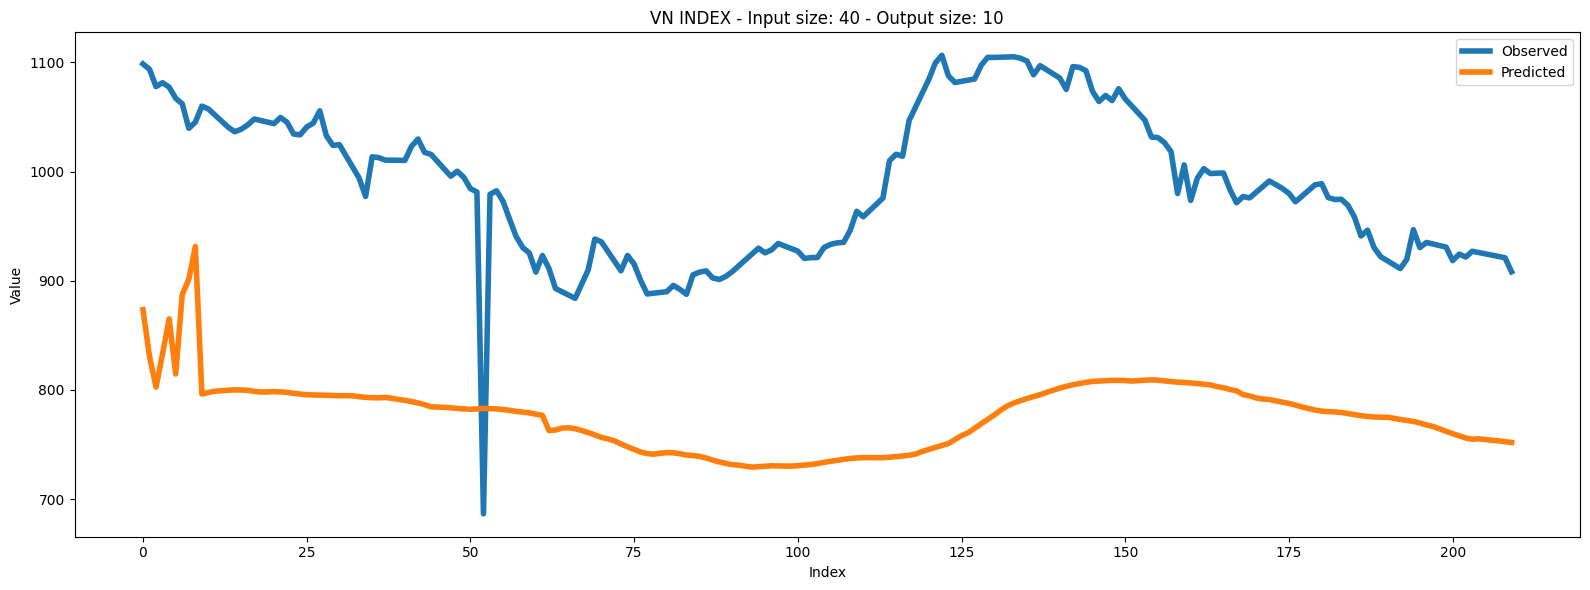

In [67]:
plot_continuous(observed_full, predicted_full, figsize=(16, 6), linewidth=4)

In [ ]:
# for slot in range(NUMBER_OF_TEST_WINDOW // OUTPUT_SIZE):
#     plot_continuous(
#         data[
#             test_set_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * slot : test_set_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * (slot + 1)
#         ],
#         predicted_full[OUTPUT_SIZE * slot : OUTPUT_SIZE * (slot + 1)],
#         figsize=(16, 6),
#         linewidth=4,
#     )

### Calculate R^2

In [68]:
import numpy as np


def r2_score(observed, predicted):
    observed = np.array(observed)
    predicted = np.array(predicted)

    ss_res = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares

    return 1 - (ss_res / ss_tot)

In [69]:
print(r2_score(observed_full, predicted_full))

-2243.878364341179


In [ ]:
# tensorboard --logdir=src/model/lightning_logs/